In [1]:
#Linear Neural Network for classification

%matplotlib inline
import time
import torch
import torchvision
from torchvision import transforms
from d2l import torch as d2l
d2l.use_svg_display()

In [2]:
class FashionMNIST(d2l.DataModule): #@save
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()
        trans = transforms.Compose([transforms.Resize(resize), transforms.ToTensor()])
        self.train = torchvision.datasets.FashionMNIST(root=self.root, train=True, transform=trans, download=True)
        self.val = torchvision.datasets.FashionMNIST(root=self.root, train=False, transform=trans, download=True)

In [3]:
data = FashionMNIST(resize=(32, 32))

In [4]:
data.train[0][0].shape

torch.Size([1, 32, 32])

In [5]:
@d2l.add_to_class(FashionMNIST)
def text_labels(self, indices):
    labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
              'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [labels[int(i)] for i in indices]

In [6]:
@d2l.add_to_class(FashionMNIST)
def get_dataloader(self, train):
    data = self.train if train else self.val
    return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
                                       num_workers=self.num_workers)


In [7]:
X, y = next(iter(data.train_dataloader()))
print(X.shape, X.dtype, y.shape, y.dtype)

torch.Size([64, 1, 32, 32]) torch.float32 torch.Size([64]) torch.int64


In [8]:
start = time.time()
for batch in data.train_dataloader():
    continue
print('%.2f sec' % (time.time() - start))

7.44 sec


In [9]:
@d2l.add_to_class(FashionMNIST) #@save
def visualize(self, batch, nrows=1, ncols=8, labels=[]):
    X, y = batch
    if not labels:
        labels = self.text_labels(y)
    d2l.show_images(X.squeeze(1), nrows, ncols, titles=labels)


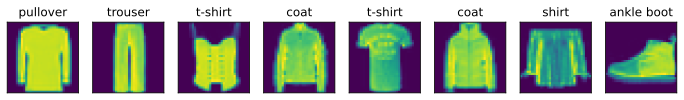

In [10]:
batch = next(iter(data.train_dataloader()))
data.visualize(batch)

In [11]:
#Checking data load time with different batch sizes
for batch_size in [2, 4, 8, 16, 32, 64, 128]:
    data = FashionMNIST(batch_size=batch_size)
    start = time.time()
    for batch in data.train_dataloader():
        continue
    print('batch size %d: %.2f sec' % (batch_size, time.time() - start))


batch size 2: 14.09 sec
batch size 4: 9.08 sec
batch size 8: 8.76 sec
batch size 16: 8.41 sec
batch size 32: 8.04 sec
batch size 64: 7.86 sec
batch size 128: 8.44 sec


In [12]:
class FashionMNISTWithoutTransform(d2l.DataModule): #@save
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()
        start = time.time()
        self.train = torchvision.datasets.FashionMNIST(root=self.root, train=True, download=True)
        print('%.2f sec' % (time.time() - start))
        self.val = torchvision.datasets.FashionMNIST(root=self.root, train=False, download=True)

    def get_dataloader(self, train):
        data = self.train.data if train else self.val.data
        return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
                                           num_workers=self.num_workers)
    

In [13]:
#Verifying that data is bought in memory by MNIST class when an instance is created
from torchvision import datasets, transforms
import psutil, os

before = psutil.Process(os.getpid()).memory_info().rss / 1e6
dataset = datasets.MNIST(root='./data', train=True, download=True)
after = psutil.Process(os.getpid()).memory_info().rss / 1e6

print(f"Memory increased by {after - before:.2f} MB")

#Observaton:
#When the data instance is created first time, there is increase in memory consumption by around 48MB.
#When we re-run the cell, the change in memory consumption is almost zero. This is due to OS internal caching and 
#Pytorch memory pooling.


Memory increased by 47.04 MB


In [14]:
class FashionMNISTWithDifferentWorkers(d2l.DataModule): #@save
    def __init__(self, batch_size=64, resize=(28, 28), num_workers=4):
        super().__init__()
        self.save_hyperparameters()
        self.train = torchvision.datasets.FashionMNIST(root=self.root, train=True, download=True)
        self.val = torchvision.datasets.FashionMNIST(root=self.root, train=False, download=True)

    def get_dataloader(self, train):
        data = self.train.data if train else self.val.data
        return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
                                           num_workers=self.num_workers)
    

In [15]:
num_workers = [0, 1, 2, 4]

for num_worker in num_workers:
    data = FashionMNISTWithDifferentWorkers(num_workers=num_worker)
    start = time.time()
    for batch in data.train_dataloader():
        continue
    print(num_worker , " : " ,'%.2f sec' % (time.time() - start))

0  :  0.29 sec
1  :  3.68 sec
2  :  3.58 sec
4  :  4.39 sec


In [16]:
class Classifier(d2l.Module):
    def validation_step(self, batch):
        Y_hat = self(*batch[:-1])
        self.plot('loss', self.loss(Y_hat, batch[-1]), train=False)
        self.plot('accuracy', self.accuracy(Y_hat, batch[-1]), train=False)

    def accuracy(self, Y_hat, Y, average=True):
        Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
        preds = Y_hat.argmax(axis=1).type(Y.dtype)
        compare = (preds == Y.reshape(-1)).type(torch.float32)
        return compare.mean() if average else compare

In [17]:
@d2l.add_to_class(d2l.Module) #@save
def configure_optimizer(self):
    return torch.optim.SGD(self.parameters(), lr=self.lr)
